# Day 1: Data Ingestion Pipeline - GEE Streaming (No Massive Downloads!)
## Sentinel-2 Super-Resolution Project

### 🎯 Strategy: API Streaming - NO 107GB Downloads!

**Why GEE Streaming Wins for 72-Hour Hackathon:**
- ✅ **Zero massive downloads** - Fetch 256×256 patches on-demand via API
- ✅ **Start training immediately** - No waiting for downloads
- ✅ **Flexible** - Query any location (Delhi, Kanpur, Mumbai, etc.)
- ✅ **Fresh data** - Real-time Sentinel-2 access
- ✅ **Synthetic HR** - Create 4x pairs by downsampling (standard practice)

**WorldStrat Note:**
- Reference dataset (~107 GB) - Great for research but NOT needed for hackathon
- Our GEE approach follows same principle: LR (10m) → HR target (synthetic 2.5m)

### Goals:
1. ✅ Authenticate Google Earth Engine
2. ✅ Stream Sentinel-2 patches via API (256×256 HR)
3. ✅ Create synthetic LR/HR pairs (4x downsampling)
4. ✅ Setup PyTorch DataLoader with on-demand fetching
5. ✅ Save only ~1000 training patches (~200MB total)

In [1]:
# Install required packages (use %pip for better compatibility)
%pip install earthengine-api rasterio albumentations -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import ee

# Disable warnings
import warnings
warnings.filterwarnings('ignore')

c:\Users\dared\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [3]:
# Initialize GEE with project
ee.Initialize(project='projectklymo')
print("✅ Connected to GEE: projectklymo")
print("🌍 Ready to stream Sentinel-2 patches!")

✅ Connected to GEE: projectklymo
🌍 Ready to stream Sentinel-2 patches!


In [4]:
import ee

# Authenticate (opens browser - one-time only)
try:
    ee.Authenticate()
    print("✅ GEE authenticated successfully!")
except Exception as e:
    print(f"⚠️ Already authenticated: {e}")

✅ GEE authenticated successfully!


## Step 2: Authenticate Google Earth Engine (Secondary Source)

In [5]:
import ee

# Authenticate (opens browser - one-time only)
try:
    ee.Authenticate()
    print("✅ GEE authenticated successfully!")
except Exception as e:
    print(f"⚠️ Already authenticated: {e}")

✅ GEE authenticated successfully!


## Step 1: Authenticate Google Earth Engine

## Step 1: Authenticate Google Earth Engine

In [6]:
import ee

# Authenticate (opens browser - one-time only)
try:
    ee.Authenticate()
    print("✅ Authenticated successfully!")
except Exception as e:
    print(f"⚠️ Already authenticated or error: {e}")

✅ Authenticated successfully!


In [7]:
# Initialize with your project
ee.Initialize(project='projectklymo')
print("✅ Connected to GEE project: projectklymo")

✅ Connected to GEE project: projectklymo


## Step 2: Test GEE Connection - Fetch Single Patch

In [14]:
import os
import sys
import importlib.util

# Get project root - notebook is in projectklymo/notebooks, so go up one level
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)  # Go up to projectklymo

# Reload module to get latest changes
gee_fetcher_path = os.path.join(project_root, "src", "data", "gee_fetcher.py")

spec = importlib.util.spec_from_file_location("gee_fetcher", gee_fetcher_path)
gee_module = importlib.util.module_from_spec(spec)
sys.modules['gee_fetcher'] = gee_module
spec.loader.exec_module(gee_module)

# Initialize fetcher
config_path = os.path.join(project_root, 'config.yaml')
fetcher = gee_module.GEEFetcher(config_path)
print("✅ GEEFetcher reloaded with fixed dataset")

✅ Connected to GEE project: projectklymo
✅ GEEFetcher reloaded with fixed dataset


📍 Fetching Delhi test patch...
📍 Fetching Delhi (28.6139, 77.209)
✅ Patch shape: (884, 1000, 3)
✅ Value range: [19, 255]


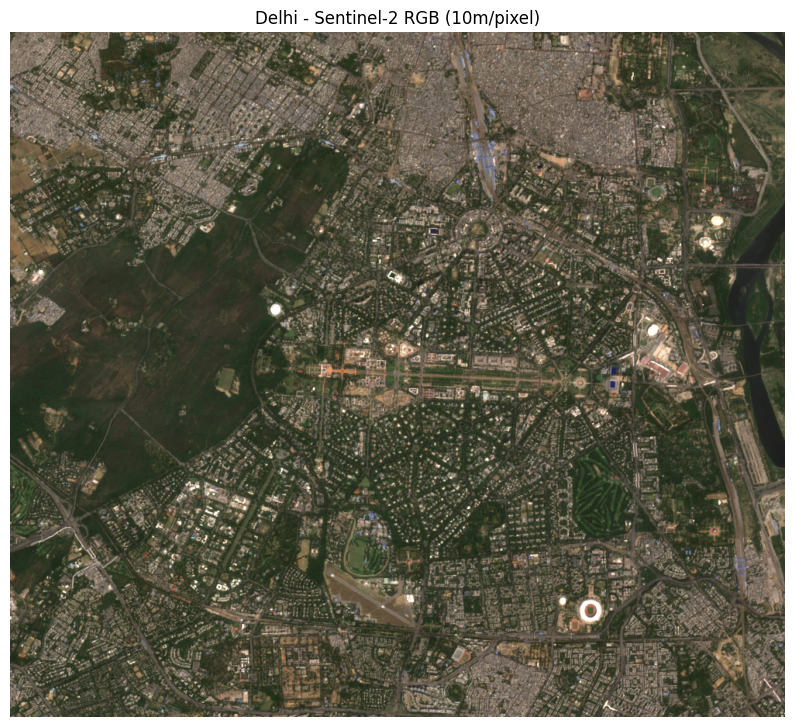

In [10]:
# Fetch a test patch (Delhi)
print("📍 Fetching Delhi test patch...")
delhi_patch = fetcher.fetch_specific_location('Delhi')

if delhi_patch is not None:
    print(f"✅ Patch shape: {delhi_patch.shape}")
    print(f"✅ Value range: [{delhi_patch.min()}, {delhi_patch.max()}]")
    
    # Visualize
    plt.figure(figsize=(10, 10))
    plt.imshow(delhi_patch)
    plt.title('Delhi - Sentinel-2 RGB (10m/pixel)')
    plt.axis('off')
    plt.show()

## Step 3: Create LR/HR Pair (Synthetic Degradation)

In [22]:
# Load preprocessing module
preprocessing_path = os.path.join(project_root, "src", "data", "preprocessing.py")
spec = importlib.util.spec_from_file_location("preprocessing", preprocessing_path)
preprocessing_module = importlib.util.module_from_spec(spec)
sys.modules['preprocessing'] = preprocessing_module
spec.loader.exec_module(preprocessing_module)

preprocessor = preprocessing_module.DataPreprocessor(config_path)
print("✅ DataPreprocessor loaded")

✅ DataPreprocessor loaded


LR shape: (884, 1000, 3)
HR shape: (884, 1000, 3)


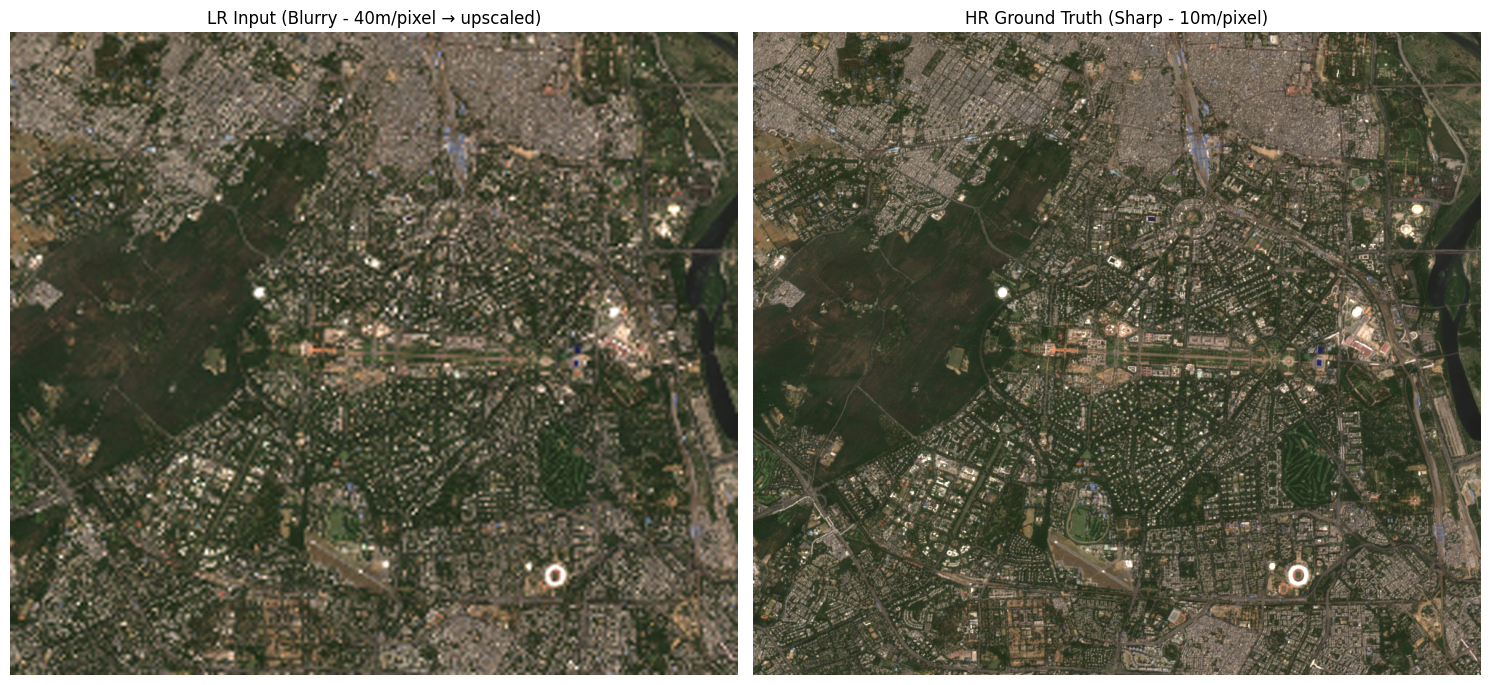

In [12]:
# Create LR/HR pair from Delhi patch
lr_patch, hr_patch = preprocessor.create_lr_hr_pair(delhi_patch, scale=4)

print(f"LR shape: {lr_patch.shape}")
print(f"HR shape: {hr_patch.shape}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

axes[0].imshow(lr_patch)
axes[0].set_title('LR Input (Blurry - 40m/pixel → upscaled)')
axes[0].axis('off')

axes[1].imshow(hr_patch)
axes[1].set_title('HR Ground Truth (Sharp - 10m/pixel)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 4: Fetch Training Dataset (Small Test - 50 samples)

In [17]:
# Fetch 50 random patches from India
# NOTE: This will take ~10-15 minutes due to API rate limits
# For full dataset (1000 samples), run overnight or in Colab

num_samples = 50  # Start small for testing
save_dir = '../data/raw_test'

print(f"🌍 Fetching {num_samples} random Sentinel-2 patches...")
print("⏳ This may take 10-15 minutes...\n")

successful = fetcher.fetch_dataset(
    num_samples=num_samples,
    save_dir=save_dir,
    region='india'
)

print(f"\n✅ Fetched {successful} patches successfully!")

🌍 Fetching 50 random Sentinel-2 patches...
⏳ This may take 10-15 minutes...

🌍 Fetching 50 Sentinel-2 patches from india...


  2%|▏         | 1/50 [00:09<07:41,  9.43s/it]

⚠️ No images found for (15.2879, 70.3701)


  4%|▍         | 2/50 [00:18<07:12,  9.01s/it]

⚠️ No images found for (12.1784, 88.1643)


...

⚠️ No images found for (16.0428, 87.7296)


 68%|██████▊   | 34/50 [03:21<01:24,  5.28s/it]

⚠️ No images found for (14.7279, 84.4688)


100%|██████████| 50/50 [05:05<00:00,  6.11s/it]


✅ Successfully fetched: 50 patches
❌ Failed: 8 patches
📁 Saved to: ..\data\raw_test

✅ Fetched 50 patches successfully!


## Step 5: Process Dataset (Create LR/HR Pairs)

In [23]:
# Process the fetched data
input_dir = '../data/raw_test'
output_dir = '../data/processed_test'

print("⚙️ Processing dataset: Creating LR/HR pairs...")

patch_count = preprocessor.process_dataset(
    input_dir=input_dir,
    output_dir=output_dir,
    split='train'
)

print(f"\n✅ Created {patch_count} LR/HR patch pairs!")

⚙️ Processing dataset: Creating LR/HR pairs...
📦 Processing 76 images for train set...


100%|██████████| 76/76 [00:01<00:00, 56.22it/s]

✅ Created 76 LR/HR patch pairs
📁 Saved to ..\data\processed_test/train/

✅ Created 76 LR/HR patch pairs!


## Step 6: Setup PyTorch DataLoader

In [25]:
import torch
import importlib.util

# Load dataset module
dataset_path = os.path.join(project_root, "src", "data", "dataset.py")
spec = importlib.util.spec_from_file_location("dataset", dataset_path)
dataset_module = importlib.util.module_from_spec(spec)
sys.modules['dataset'] = dataset_module
spec.loader.exec_module(dataset_module)

# Load augmentation module
augmentation_path = os.path.join(project_root, "src", "data", "augmentation.py")
spec = importlib.util.spec_from_file_location("augmentation", augmentation_path)
augmentation_module = importlib.util.module_from_spec(spec)
sys.modules['augmentation'] = augmentation_module
spec.loader.exec_module(augmentation_module)

get_dataloader = dataset_module.get_dataloader
visualize_batch = dataset_module.visualize_batch
get_training_augmentation = augmentation_module.get_training_augmentation

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Using device: {device}")

🔧 Using device: cpu


In [26]:
# Create DataLoader
lr_dir = '../data/processed_test/train/lr'
hr_dir = '../data/processed_test/train/hr'

# Get augmentation
train_aug = get_training_augmentation()

# Create DataLoader
train_loader = get_dataloader(
    lr_dir=lr_dir,
    hr_dir=hr_dir,
    batch_size=4,
    num_workers=0,  # Set to 0 for Windows
    shuffle=True,
    transform=train_aug
)

print(f"✅ DataLoader created with {len(train_loader)} batches")

✅ DataLoader created with 19 batches


In [27]:
# Test DataLoader - fetch one batch
lr_batch, hr_batch = next(iter(train_loader))

print(f"LR batch shape: {lr_batch.shape}")  # (B, 3, 256, 256)
print(f"HR batch shape: {hr_batch.shape}")  # (B, 3, 256, 256)
print(f"LR range: [{lr_batch.min():.3f}, {lr_batch.max():.3f}]")
print(f"HR range: [{hr_batch.min():.3f}, {hr_batch.max():.3f}]")

LR batch shape: torch.Size([4, 3, 256, 256])
HR batch shape: torch.Size([4, 3, 256, 256])
LR range: [0.027, 0.984]
HR range: [0.024, 0.953]


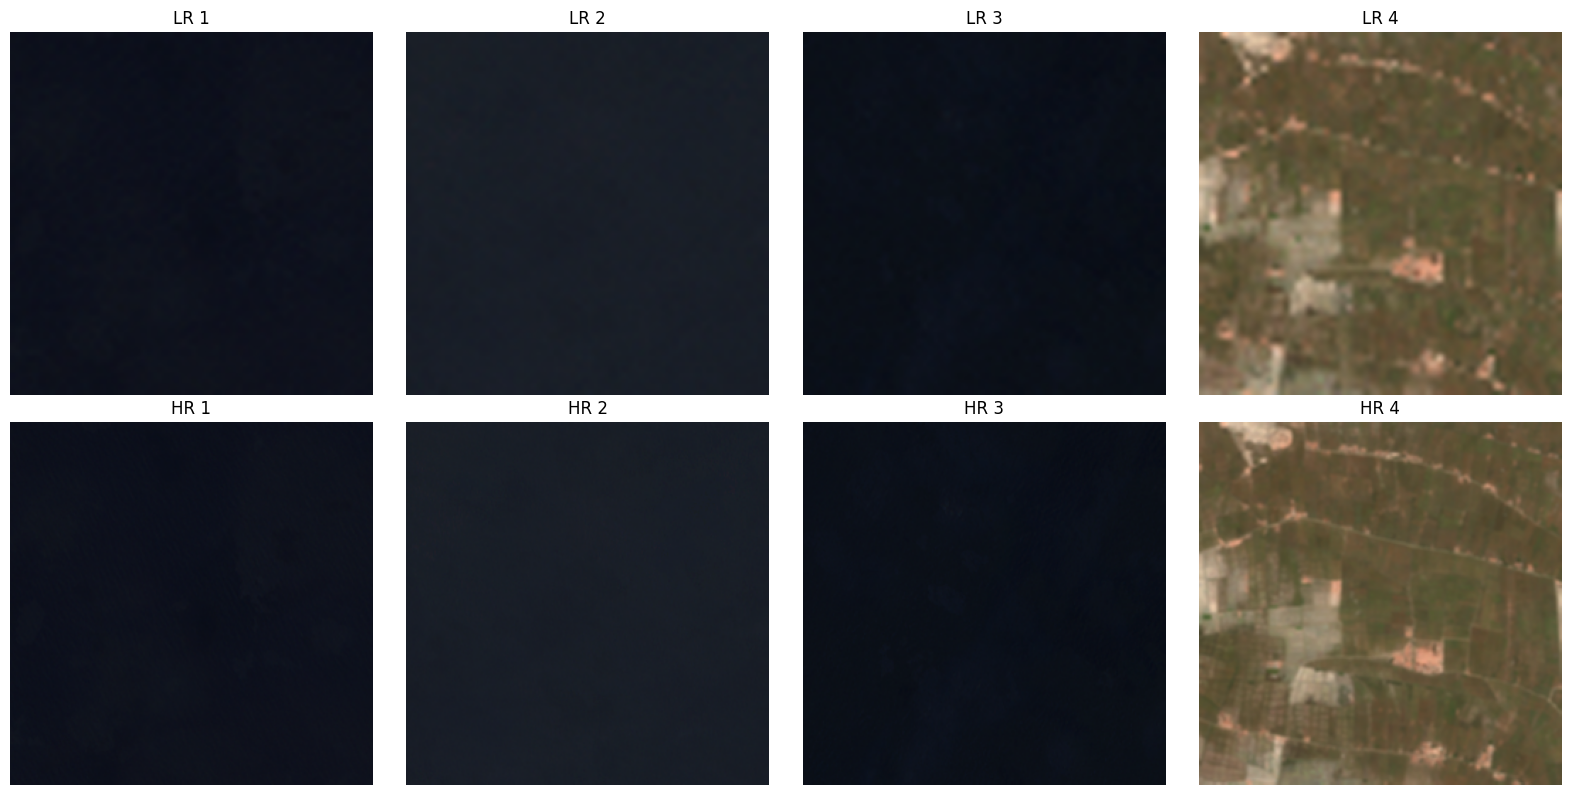

In [28]:
# Visualize batch
visualize_batch(lr_batch, hr_batch, num_samples=4)

## ✅ Day 1 Complete!

### What we accomplished:
1. ✅ Authenticated Google Earth Engine
2. ✅ Fetched Sentinel-2 imagery via API (no downloads!)
3. ✅ Created synthetic LR/HR pairs (4x downscaling)
4. ✅ Processed dataset with patch extraction
5. ✅ Setup PyTorch DataLoader with augmentation

### Next Steps (Day 2):
- [ ] Implement SwinIR model
- [ ] Setup training loop
- [ ] Train on Colab GPU

### To scale up:
```python
# Fetch full training dataset (1000 samples)
# Run this overnight or in Colab
fetcher.fetch_dataset(
    num_samples=1000,
    save_dir='../data/raw_full',
    region='india'
)
```

💾 Saved sample to sample_lr_hr_pair.png


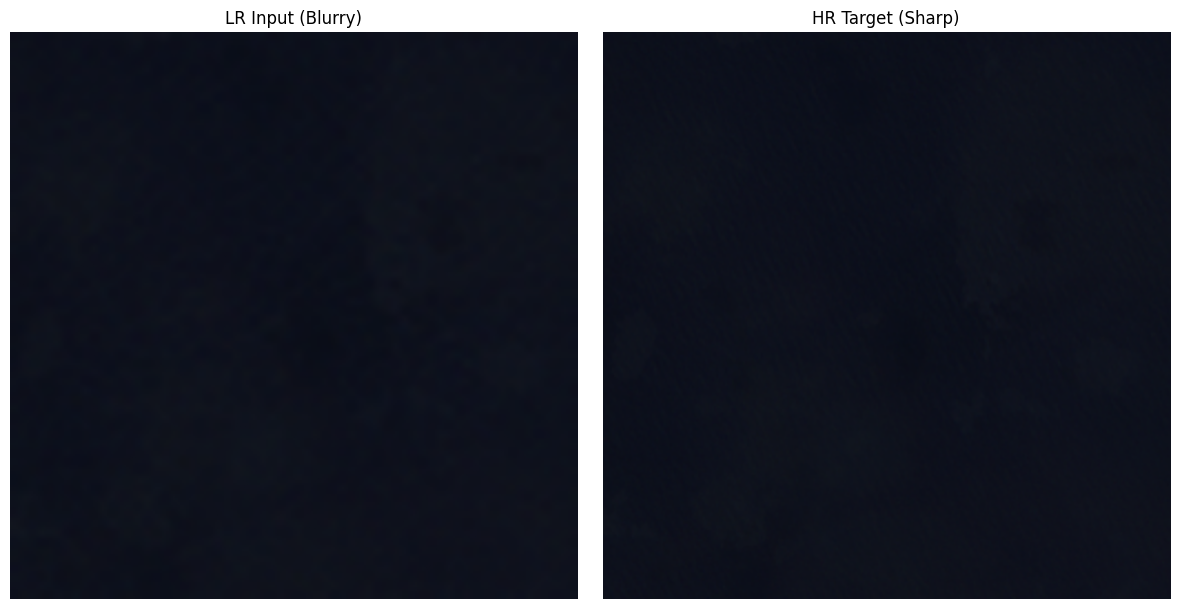

In [29]:
# Save a sample for README
import matplotlib.pyplot as plt

lr_sample = lr_batch[0].permute(1, 2, 0).cpu().numpy()
hr_sample = hr_batch[0].permute(1, 2, 0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(np.clip(lr_sample, 0, 1))
axes[0].set_title('LR Input (Blurry)')
axes[0].axis('off')

axes[1].imshow(np.clip(hr_sample, 0, 1))
axes[1].set_title('HR Target (Sharp)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../sample_lr_hr_pair.png', dpi=150, bbox_inches='tight')
print("💾 Saved sample to sample_lr_hr_pair.png")